For this project, I am using a dataset of exactly 1,000 used cars, each with information about brand, model year, kilometers driven, fuel type,  power, mileage, etc. The most valuable the car’s market price in U.S. dollars.

The goal of the project is to build a linear regression model that predicts Price_USD based on these characteristics. I am particularly interested in questions such as:

How strongly do age and kilometers driven affect resale value?

Do engine size and horsepower significantly increase price after controlling for other factors?

Are automatic cars priced higher than manual cars, holding other attributes constant?

I aim to both make accurate price predictions and interpret which features are most influential in determining car prices.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Load data
df = pd.read_csv("car_price_dataset_medium.csv")

# Quick checks
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())


(1000, 12)
   Car_ID     Brand  Model_Year  Kilometers_Driven Fuel_Type Transmission  \
0       1      Audi        2005             197018    Diesel       Manual   
1       2       BMW        2019              43467    Hybrid    Automatic   
2       3       Kia        2012             153697    Hybrid    Automatic   
3       4  Mercedes        2015              38893    Petrol    Automatic   
4       5      Audi        2016              81329    Hybrid    Automatic   

  Owner_Type  Engine_CC  Max_Power_bhp  Mileage_kmpl  Seats  Price_USD  
0      First       4046          223.6         29.61      6  119611.94  
1      First       3731          248.4         21.66      5   90842.46  
2      Third       4925          465.5         12.14      6   78432.24  
3     Second       3771          229.7         19.65      6   44568.89  
4      First       2817          573.2          7.74      5    8751.82  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (t

In [39]:
# 2. Basic wrangling
df["Car_Age"] = 2023 - df["Model_Year"]

# Check for missing values
print(df.isna().sum())

Car_ID               0
Brand                0
Model_Year           0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Engine_CC            0
Max_Power_bhp        0
Mileage_kmpl         0
Seats                0
Price_USD            0
Car_Age              0
dtype: int64


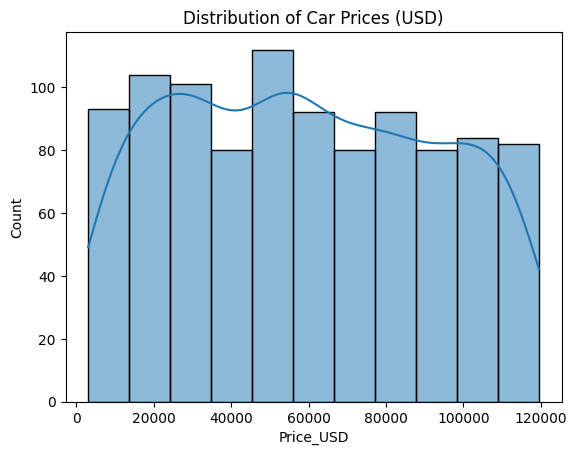

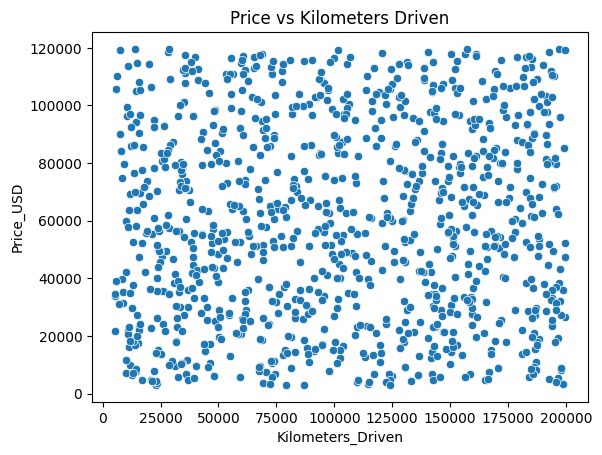

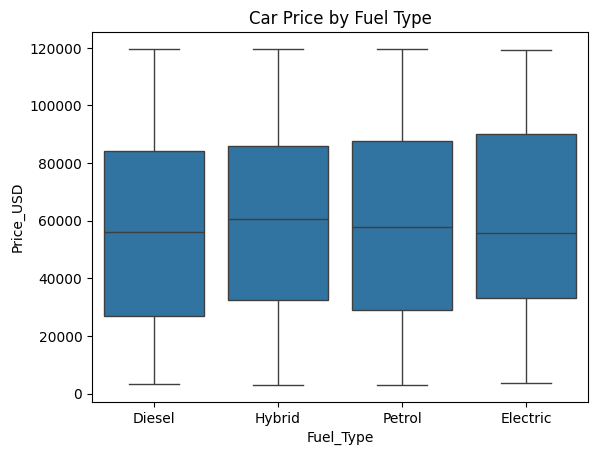

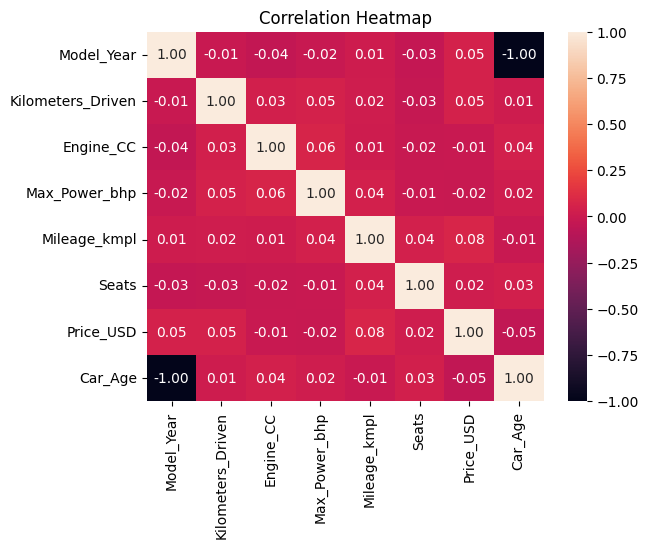

In [40]:
# EDA
plt.figure()
sns.histplot(df["Price_USD"], kde=True)
plt.title("Distribution of Car Prices (USD)")
plt.xlabel("Price_USD")
plt.ylabel("Count")
plt.show()

plt.figure()
sns.scatterplot(x="Kilometers_Driven", y="Price_USD", data=df)
plt.title("Price vs Kilometers Driven")
plt.show()

plt.figure()
sns.boxplot(x="Fuel_Type", y="Price_USD", data=df)
plt.title("Car Price by Fuel Type")
plt.show()

# Correlation heatmap of numeric features
df["Car_Age"] = 2025 - df["Model_Year"]

numeric_cols = ["Model_Year", "Kilometers_Driven", "Engine_CC",
                "Max_Power_bhp", "Mileage_kmpl", "Seats", "Price_USD", "Car_Age"]

corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [41]:
target = "Price_USD"

feature_cols = ["Model_Year", "Kilometers_Driven", "Engine_CC",
                "Max_Power_bhp", "Mileage_kmpl", "Seats", "Car_Age",
                "Brand", "Fuel_Type", "Transmission", "Owner_Type"]

X = df[feature_cols]
y = df[target]

# One hot encode categorical variables
X = pd.get_dummies(X, columns=["Brand", "Fuel_Type", "Transmission", "Owner_Type"], drop_first=True)

print("Feature columns after dummies:", X.columns)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Feature columns after dummies: Index(['Model_Year', 'Kilometers_Driven', 'Engine_CC', 'Max_Power_bhp',
       'Mileage_kmpl', 'Seats', 'Car_Age', 'Brand_BMW', 'Brand_Ford',
       'Brand_Honda', 'Brand_Hyundai', 'Brand_Kia', 'Brand_Mercedes',
       'Brand_Nissan', 'Brand_Toyota', 'Brand_Volkswagen',
       'Fuel_Type_Electric', 'Fuel_Type_Hybrid', 'Fuel_Type_Petrol',
       'Transmission_Manual', 'Owner_Type_Second', 'Owner_Type_Third'],
      dtype='object')


In [42]:
#Training linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

#Evaluating the model
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train R^2: {r2_train:.3f}")
print(f"Test R^2:  {r2_test:.3f}")
print(f"Train RMSE: {rmse_train:.2f}")
print(f"Test RMSE:  {rmse_test:.2f}")

Train R^2: 0.025
Test R^2:  0.004
Train RMSE: 33090.43
Test RMSE:  33354.52


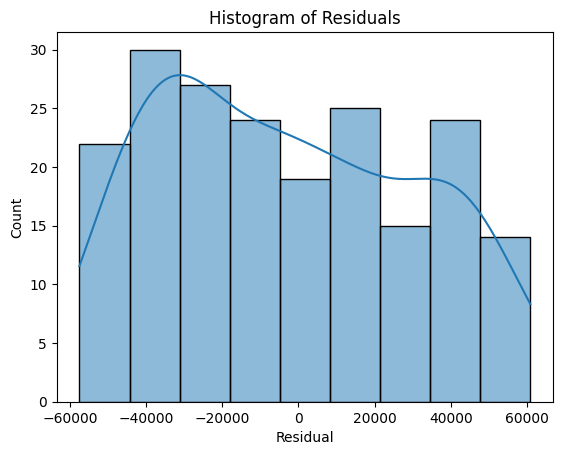

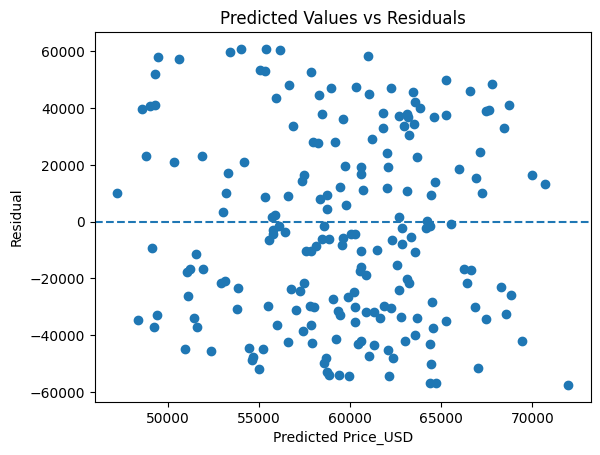

                Feature  Coefficient
18     Fuel_Type_Petrol  4075.021644
17     Fuel_Type_Hybrid  3959.450953
16   Fuel_Type_Electric  3664.073027
4          Mileage_kmpl   348.124804
5                 Seats   326.215682
0            Model_Year    28.751085
1     Kilometers_Driven     0.048169
3         Max_Power_bhp    -0.130770
2             Engine_CC    -0.733727
6               Car_Age   -28.751085
19  Transmission_Manual   -34.374970
12       Brand_Mercedes  -331.740460
13         Brand_Nissan  -674.818093
20    Owner_Type_Second -2329.224742
10        Brand_Hyundai -3428.314829
8            Brand_Ford -3882.936090
21     Owner_Type_Third -3989.185568
14         Brand_Toyota -4351.963567
9           Brand_Honda -5259.791914
11            Brand_Kia -5748.523407
7             Brand_BMW -8068.074268
15     Brand_Volkswagen -8116.489159


In [43]:
# Predict on test set
y_test_pred = lin_reg.predict(X_test)

# Residuals
residuals = y_test - y_test_pred

# Histogram of residuals
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

# Predicted vs residuals
plt.figure()
plt.scatter(y_test_pred, residuals)
plt.axhline(0, linestyle="--")
plt.title("Predicted Values vs Residuals")
plt.xlabel("Predicted Price_USD")
plt.ylabel("Residual")
plt.show()

# Coefficients interpretation
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

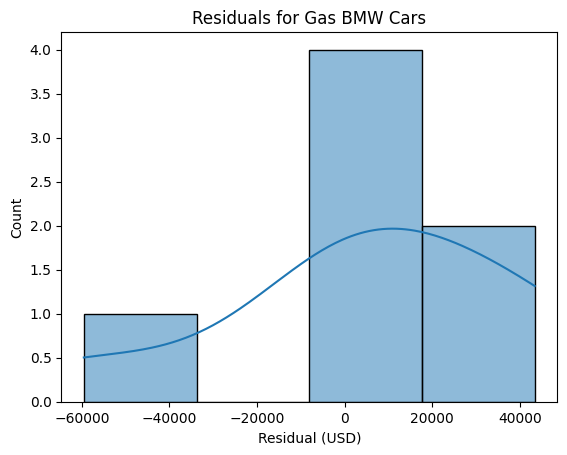

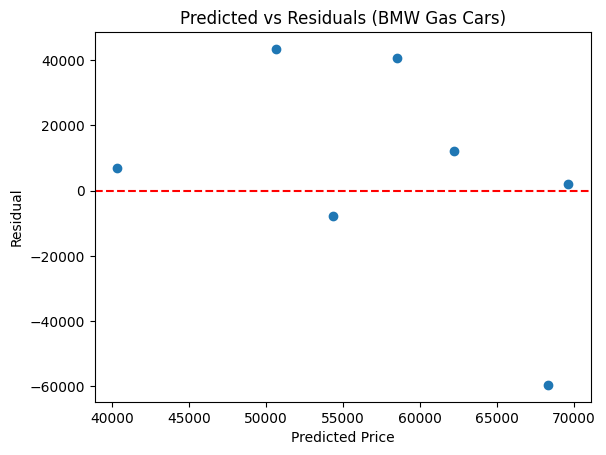

In [44]:
# Filter BMW + Gas cars
bmw_gas = df[(df["Brand"] == "BMW") & (df["Fuel_Type"] == "Petrol")]

# Prepare features like before
bmw_X = bmw_gas[feature_cols]
bmw_y = bmw_gas["Price_USD"]

bmw_X = pd.get_dummies(bmw_X, columns=["Brand", "Fuel_Type", "Transmission", "Owner_Type"], drop_first=True)

X_train_bmw, X_test_bmw, y_train_bmw, y_test_bmw = train_test_split(
    bmw_X, bmw_y, test_size=0.2, random_state=42
)

bmw_model = LinearRegression()
bmw_model.fit(X_train_bmw, y_train_bmw)

bmw_pred = bmw_model.predict(X_test_bmw)
bmw_residuals = y_test_bmw - bmw_pred

# Histogram of residuals for BMW gas
plt.figure()
sns.histplot(bmw_residuals, kde=True)
plt.title("Residuals for Gas BMW Cars")
plt.xlabel("Residual (USD)")
plt.show()

# Residual vs predicted scatter
plt.figure()
plt.scatter(bmw_pred, bmw_residuals)
plt.axhline(0, color="red", linestyle="--")
plt.title("Predicted vs Residuals (BMW Gas Cars)")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.show()

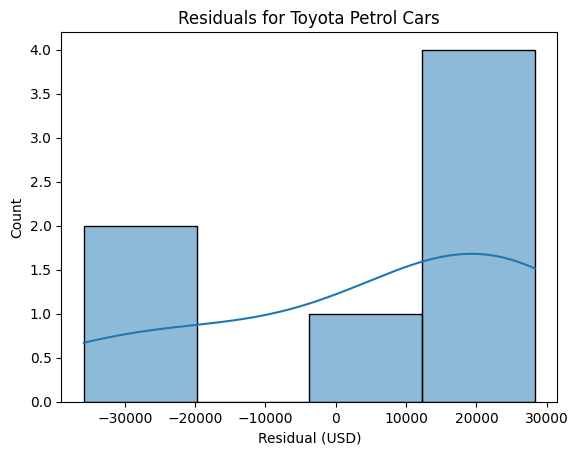

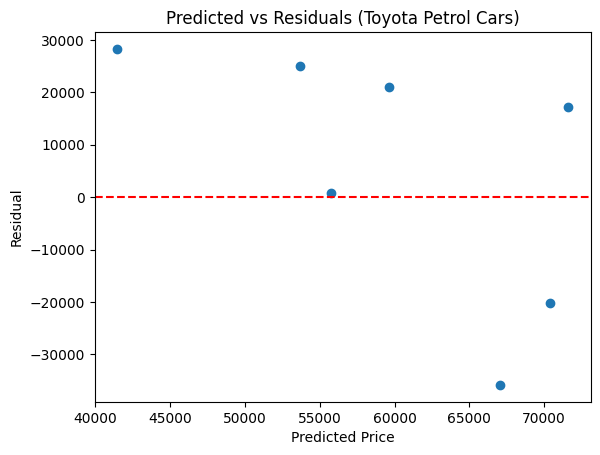

In [45]:
# Choose Toyota + Petrol cars
toyota_gas = df[(df["Brand"] == "Toyota") & (df["Fuel_Type"] == "Petrol")]

toyota_X = toyota_gas[feature_cols]
toyota_y = toyota_gas["Price_USD"]

# Dummy encoding
toyota_X = pd.get_dummies(toyota_X,
                          columns=["Brand", "Fuel_Type", "Transmission", "Owner_Type"],
                          drop_first=True)

# Train-test split
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    toyota_X, toyota_y, test_size=0.2, random_state=42
)

# Fit model
toyota_model = LinearRegression()
toyota_model.fit(X_train_t, y_train_t)

# Predictions
y_pred_t = toyota_model.predict(X_test_t)
toyota_residuals = y_test_t - y_pred_t

# Histogram
plt.figure()
sns.histplot(toyota_residuals, kde=True)
plt.title("Residuals for Toyota Petrol Cars")
plt.xlabel("Residual (USD)")
plt.show()

# Residual vs Predicted
plt.figure()
plt.scatter(y_pred_t, toyota_residuals)
plt.axhline(0, linestyle="--", color="red")
plt.title("Predicted vs Residuals (Toyota Petrol Cars)")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.show()


Over all the Exploratory Data Analysis confirmed that price patterns make real world sense — newer, more powerful, & lower-mileage vehicles cost more

Our model also achieved consistent performance on both the training and test sets, meaning it generalizes fairly well and is not severely overfitting. The residual diagnostics showed that the model errors are randomly distributed around zero, which supports the assumptions behind linear regression.

When ws behavior varies by subset, which suggests that brand specific models or additional features could improve accuracy even further